In [ ]:
import gc
import glob
import importlib
import inspect
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import gpytorch

from pyuvdata import UVData
import bayeslim as ba
import gprlim
from gprlim import kernels
from bayeslim.fft import FFT


# ============================================================
# Local modules
# ============================================================

sys.path.append("./")
sys.path.append("../../")

import utils_load
from utils_load import save_vd_inp, load_vd_inp

import gp_utils
importlib.reload(gp_utils)

import utils_Vtau4
importlib.reload(utils_Vtau4)

from utils_Vtau4 import (
    coherent_reference_average,
    coherent_inpaint_average,
    create_delay_figure,
    get_delay_quantities,
    get_ratio_hist_values,
    get_horizon_delay_ns,
    plot_delay_histograms,
    plot_reference_delay_curves,
    plot_method_curves,
    plot_ratio_inset,
    plot_ratio_histogram,
    make_ratio_label,
    format_delay_axis,
    format_delay_hist_axis,
    format_ratio_axis,
    format_ratio_inset_axis,
    format_ratio_hist_axis,
    finalize_delay_figure,
)


print("gprlim path:")
print(gprlim.__file__)

print("\nutils_load module path:")
print(inspect.getmodule(save_vd_inp).__file__)

print("\ngp_utils path:")
print(gp_utils.__file__)

print("\nutils_Vtau4 path:")
print(utils_Vtau4.__file__)


gpytorch.settings.max_cholesky_size._set_value(1_000)
torch.set_default_dtype(torch.float64)

device = "cpu"


# ============================================================
# 1. Input data
# ============================================================

flag_file = (
    "/Users/alliswell48/radio_gpr_work/shao1/1.ideal_mock/"
    "gpr_data/version2/"
    "zen.h6c_idr3.2459951.flag_waterfall_round2.npz"
)

freq_chans = range(0, 600)
time_ints = range(80, 1680)

# Ideal simulation:
# dfile = "gpr_data/version2/zen.h6c_idr2_validation.sum.uvh5"

# Corrupted/coupled simulation:
dfile = sorted(
    glob.glob(
        "/Volumes/YUNYUNShao/gpr_data/corrupted data/"
        "zen.h6c_idr2_validation.24582*.sum.coupled.h5"
    )
)

if len(dfile) == 0:
    raise FileNotFoundError("No input visibility files matched dfile.")


# ============================================================
# 2. Optional data modifications
# ============================================================

inflate_data = False
add_gains = False
add_noise = False
add_reflection = False


# ============================================================
# 3. Inpainting methods
# ============================================================

inpaint_method_all = ["2d_1d", "1d_1d"]

# Other possible choices:
# inpaint_method_all = ["2d", "2d_1d", "1d_1d", "freq"]


# ============================================================
# 4. Time chunk size
# ============================================================

Ntime_chunks = 200


# ============================================================
# 5. Real flags
# ============================================================

add_real_flags = False


# ============================================================
# 6. Simulated flag patterns
# ============================================================

flag_types_all = [
    "narrowband_full_time",
    "wideband_full_time",
    "ultraband_short_time",
    "fullband_short_time",
    "narrowband_short_time",
    "narrowband_long_time",
    "wideband_long_time",
    "randn",
]


# ============================================================
# 7. Polarization and baselines
# ============================================================

polsi = "ee"
blall = [(0, 1), (0, 5), (0, 10)]
#blall = [ (0, 5)]


# ============================================================
# 8. Saved inpainting results
# ============================================================

inpaint_root_dir = (
    "/Volumes/YUNYUNShao/"
    "radio_gpr_work_great_lake/"
    "3.shao_instru/inpaint_results"
)


# ============================================================
# 9. Load autocorrelation and metadata
# ============================================================

vd_auto, meta_auto = gp_utils.load_uvdata(
    dfile,
    bls=[(0, 0)],
    pols=[polsi],
    time_ints=time_ints,
    freq_chans=freq_chans,
)

autocorr = vd_auto.data[0, 0]

freqs = meta_auto["freqs"] / 1e6
lsts = meta_auto["lsts"]
times = (meta_auto["times"] - meta_auto["times"][0]) * 24 * 3600

Ntimes = len(times)
Nfreqs = len(freqs)

reds = meta_auto["reds"]
antp = meta_auto["antp"]

ants = list(antp.keys())
antpos = torch.stack(list(antp.values()))

red_bls = meta_auto["bls"]
all_pols = meta_auto["pols"]

integration_time_s = np.diff(meta_auto["times"])[0] * 24 * 3600
channel_width_hz = np.diff(meta_auto["freqs"])[0]

noise_amp = autocorr.real / np.sqrt(
    integration_time_s * channel_width_hz
)

print("Ntimes:", Ntimes)
print("Nfreqs:", Nfreqs)
print("Polarization:", polsi)

# The autocorrelation object is no longer needed after noise_amp is computed.
del vd_auto
gc.collect()


# ============================================================
# 10. Loop over baselines
# ============================================================

for bl in blall:

    # --------------------------------------------------------
    # Identify redundant group and horizon delay
    # --------------------------------------------------------

    red_ind = np.where([bl in red for red in reds])[0][0]
    bls = reds[red_ind][:]

    representative_bl = bls[0]
    bl_vec = (
        antp[representative_bl[1]]
        - antp[representative_bl[0]]
    )
    bl_len = bl_vec.norm()

    tau_horizon = get_horizon_delay_ns(bl_len)

    print("\n" + "=" * 70)
    print(f"Baseline: {bl}")
    print(f"Baseline length: {float(bl_len):.3f} m")
    print(f"Horizon delay: {tau_horizon:.3f} ns")
    print("=" * 70)


    # --------------------------------------------------------
    # Load all baselines in this redundant group
    # --------------------------------------------------------

    vd, meta = gp_utils.load_uvdata(
        dfile,
        bls=bls,
        time_ints=time_ints,
        freq_chans=freq_chans,
        pols=[polsi],
        device=device,
    )


    # --------------------------------------------------------
    # Optional modifications
    # --------------------------------------------------------

    if inflate_data and vd.Nbls == 1:
        vd = vd.inflate_by_redundancy(
            bls=reds[red_ind]
        )

    if add_reflection:
        reflection = (
            torch.exp(
                2j * np.pi * 2000e-9 * freqs * 1e6
            )
            + torch.exp(
                -2j * np.pi * 2000e-9 * freqs * 1e6
            )
        )
        vd.data *= 1 + 1e-2 * reflection

    if add_gains:
        gains = (
            torch.randn(
                vd.Nbls,
                device=vd.data.device,
            )
            / 10
            + 1
        )
        vd.data *= gains[:, None, None]


    # --------------------------------------------------------
    # Noise-only reference
    # --------------------------------------------------------

    ns_draw = (
        torch.randn_like(vd.data)
        * noise_amp
        * 1e-10
    )

    if add_noise:
        ns_draw = (
            torch.randn_like(vd.data)
            * noise_amp
            * 1e-6
        )
        vd.data += ns_draw


    # --------------------------------------------------------
    # Frequency-to-delay Fourier transform
    # --------------------------------------------------------

    FT1 = FFT(
        dim=-1,
        N=vd.data.shape[-1],
        ndim=2,
        window="bh",
        dx=(freqs[1] - freqs[0]) / 1e3,
    )


    # ========================================================
    # Loop over flagging patterns
    # ========================================================

    for flag_idx, flag_typesi in enumerate(flag_types_all):

        flag_types = [flag_typesi]
        flag_N = [20]


        # ----------------------------------------------------
        # Figure title
        # ----------------------------------------------------

        if flag_typesi is None:
            flag_title = (
                "Real Flags"
                if add_real_flags
                else "No Flags"
            )
        elif add_real_flags:
            flag_title = (
                "Real Flags + "
                + flag_typesi.replace("_", " ").title()
            )
        else:
            flag_title = flag_typesi.replace("_", " ").title()

        print(f"Plotting: {flag_title}")


        # ----------------------------------------------------
        # Simulated flags
        # ----------------------------------------------------

        flags = gp_utils.simulate_flags(
            flag_types,
            flag_N,
            Ntimes,
            Nfreqs,
            seed=0,
        ).bool()

        if add_gains:
            flags = flags.expand(
                vd.data.shape[-3:]
            ).clone()

            for i in range(1, vd.Nbls):
                flags[i] = gp_utils.simulate_flags(
                    flag_types,
                    flag_N,
                    Ntimes,
                    Nfreqs,
                    seed=i,
                ).bool()


        # ----------------------------------------------------
        # Add real flags
        # ----------------------------------------------------

        if add_real_flags:
            real_flags = np.load(flag_file)["flags"][
                time_ints
            ][:, freq_chans, 0]

            real_flags = torch.as_tensor(
                real_flags,
                dtype=torch.bool,
                device=device,
            )

            flags = flags | real_flags


        # ----------------------------------------------------
        # Noise variance
        # ----------------------------------------------------

        noise_var = (
            noise_amp.pow(2)
            .expand(flags.shape)
            .clone()
            * 1e-5
        )

        noise_var[flags] = noise_var.mean() * 1e6


        # ====================================================
        # Figure layout
        # ====================================================

        inset_location = "upper center"

        if flag_typesi == "wideband_full_time" or flag_typesi == "wideband_long_time":
            inset_location = "upper left"

        (
            fig,
            ax_delay,
            ax_delay_hist,
            ax_ratio,
            ax_ratio_inset,
            # First stacked axis: upper histogram.
            ax_ratio_hist_horizon,
            # Second stacked axis: lower histogram.
            ax_ratio_hist_full,
        ) = create_delay_figure(
            loc0=inset_location
        )

        hist_colors = ["r", "b", "g"]
        tau_ranges = [1000, 2000, 3000]


        # ----------------------------------------------------
        # Ratio-histogram ranges
        # ----------------------------------------------------

        # Main science range.
        full_tmin = 1000.0
        full_tmax = 2000.0

        # Baseline-dependent horizon range.
        horizon_tmin = 0.0
        horizon_tmax = float(tau_horizon)


        # ====================================================
        # Compute method-independent averages only once
        # ====================================================

        (
            avg_times,
            time_wgts,
            vd_avg,
            vd_flg_avg,
            vd_ns_avg,
        ) = coherent_reference_average(
            vd=vd,
            flags=flags,
            ns_draw=ns_draw,
            Ntimes=Ntimes,
            Nelem=20,
        )

        ratio_hist_full_all = []
        ratio_hist_horizon_all = []
        delay_for_format = None


        # ====================================================
        # Loop over inpainting methods
        # ====================================================

        for inpaint_methodi in inpaint_method_all:

            # ------------------------------------------------
            # Load saved inpainted data
            # ------------------------------------------------

            vd_inp = load_vd_inp(
                root_dir=inpaint_root_dir,
                vd=vd,
                bl=bl,
                flag_typesi=flag_typesi,
                add_real_flags=add_real_flags,
                inpaint_method=inpaint_methodi,
                freq_chans=freq_chans,
                time_ints=time_ints,
                polsi=polsi,
                device=device,
                Ntime_chunks=Ntime_chunks,
            )


            # ------------------------------------------------
            # Average only the current inpainting result
            # ------------------------------------------------

            vd_inp_avg = coherent_inpaint_average(
                vd_inp=vd_inp,
                avg_times=avg_times,
                time_wgts=time_wgts,
            )


            # ------------------------------------------------
            # Delay-space quantities
            # ------------------------------------------------

            (
                p_d,
                p_i,
                data_delay,
                flg_delay,
                inp_delay,
                ns_delay,
                delay,
                ratio,
            ) = get_delay_quantities(
                vd_avg,
                vd_flg_avg,
                vd_inp_avg,
                vd_ns_avg,
                FT1,
            )

            delay_for_format = delay


            # ------------------------------------------------
            # Delay-amplitude histograms
            # ------------------------------------------------

            plot_delay_histograms(
                ax_delay_hist,
                p_d,
                p_i,
                delay,
                inpaint_methodi,
                inpaint_method_all[0],
                tau_ranges,
                hist_colors,
            )


            # ------------------------------------------------
            # Main ratio histogram: 1000–2000 ns
            # ------------------------------------------------

            ratio_hist_full = get_ratio_hist_values(
                ratio,
                delay,
                tau_min=full_tmin,
                tau_max=full_tmax,
            )

            if ratio_hist_full.size > 0:
                ratio_hist_full_all.append(
                    ratio_hist_full
                )

            full_method_label = make_ratio_label(
                inpaint_methodi,
                ratio_hist_full,
            )


            # ------------------------------------------------
            # Horizon ratio histogram
            # ------------------------------------------------

            ratio_hist_horizon = get_ratio_hist_values(
                ratio,
                delay,
                tau_min=horizon_tmin,
                tau_max=horizon_tmax,
            )

            if ratio_hist_horizon.size > 0:
                ratio_hist_horizon_all.append(
                    ratio_hist_horizon
                )

            horizon_method_label = make_ratio_label(
                inpaint_methodi,
                ratio_hist_horizon,
            )


            # ------------------------------------------------
            # Reference curves: plot once
            # ------------------------------------------------

            if inpaint_methodi == inpaint_method_all[0]:
                plot_reference_delay_curves(
                    ax_delay,
                    delay,
                    data_delay,
                    flg_delay,
                    ns_delay,
                )


            # ------------------------------------------------
            # Full delay and ratio curves
            # ------------------------------------------------

            plot_method_curves(
                ax_delay,
                ax_ratio,
                delay,
                inp_delay,
                ratio,
                inpaint_methodi,
            )


            # ------------------------------------------------
            # Ratio inset inside the horizon
            # ------------------------------------------------

            plot_ratio_inset(
                ax_ratio_inset,
                delay,
                ratio,
                inpaint_methodi,
                tau_horizon,
            )


            # ------------------------------------------------
            # Upper histogram: horizon range
            # ------------------------------------------------

            plot_ratio_histogram(
                ax_ratio_hist_horizon,
                ratio_hist_horizon,
                horizon_method_label,
            )


            # ------------------------------------------------
            # Lower histogram: 1000–2000 ns
            # ------------------------------------------------

            plot_ratio_histogram(
                ax_ratio_hist_full,
                ratio_hist_full,
                full_method_label,
            )


            # ------------------------------------------------
            # Delete method-dependent arrays
            # ------------------------------------------------

            del vd_inp
            del vd_inp_avg
            del p_i
            del inp_delay
            del ratio
            del ratio_hist_full
            del ratio_hist_horizon

            gc.collect()


        # ====================================================
        # Format all panels
        # ====================================================

        format_delay_axis(
            ax_delay,
            flag_title,
        )

        format_delay_hist_axis(
            ax_delay_hist,
        )


        # The full-range ratio panel may need more upper padding
        # for specific flagging patterns.
        upper_padding_percent = 120

        if flag_typesi == "ultraband_short_time":
            upper_padding_percent = 500
        elif flag_typesi == "narrowband_short_time":
            upper_padding_percent = 200
        elif flag_typesi == "wideband_full_time":
            upper_padding_percent = 200
        elif flag_typesi == "wideband_long_time":
            upper_padding_percent = 350


        format_ratio_axis(
            ax_ratio,
            delay=delay_for_format,
            tau_exclude=tau_horizon,
            lower_percentile=0.5,
            upper_percentile=99.5,
            lower_padding_percent=100,
            upper_padding_percent=upper_padding_percent,
        )

        format_ratio_inset_axis(
            ax_ratio_inset,
            tau_horizon,
        )


        # ----------------------------------------------------
        # Upper histogram: horizon range
        # ----------------------------------------------------

        format_ratio_hist_axis(
            ax_ratio_hist_horizon,
            ratio_hist_all=ratio_hist_horizon_all,
            x_min_fraction=1.0,
            x_max_fraction=1.0,
            tau_min=horizon_tmin,
            tau_max=horizon_tmax,
            fontsize=7,
            show_xlabel=True,
        )


        # ----------------------------------------------------
        # Lower histogram: 1000–2000 ns
        # ----------------------------------------------------

        format_ratio_hist_axis(
            ax_ratio_hist_full,
            ratio_hist_all=ratio_hist_full_all,
            x_min_fraction=1.0,
            x_max_fraction=1.0,
            tau_min=full_tmin,
            tau_max=full_tmax,
            fontsize=7,
            show_xlabel=True,
        )


        # ====================================================
        # Final layout and display
        # ====================================================

        finalize_delay_figure(
            fig,
            ax_delay,
            ax_ratio,
            flag_idx,
            bl,
            polsi,
        )

        plt.close(fig)


        # ====================================================
        # Cleanup after this flagging pattern
        # ====================================================

        del avg_times
        del time_wgts
        del vd_avg
        del vd_flg_avg
        del vd_ns_avg

        del ratio_hist_full_all
        del ratio_hist_horizon_all
        del delay_for_format
        del flags
        del noise_var

        gc.collect()


    # ========================================================
    # Cleanup after this baseline
    # ========================================================

    del vd
    del meta
    del ns_draw
    del FT1

    gc.collect()


In [ ]:
=============================================!

gprlim path:
/Users/alliswell48/gprlim/gprlim/__init__.py

utils_load module path:
/Users/alliswell48/radio_gpr_work/shao1/2.corrupt_data/utils_load.py

gp_utils path:
/Users/alliswell48/radio_gpr_work/shao1/2.corrupt_data/../../gp_utils.py

utils_Vtau4 path:
/Users/alliswell48/radio_gpr_work/shao1/2.corrupt_data/utils_Vtau4.py
Ntimes: 1600
Nfreqs: 600
Polarization: ee

Baseline: (0, 5)
Baseline length: 73.040 m
Horizon delay: 243.466 ns
Plotting: Narrowband Long Time


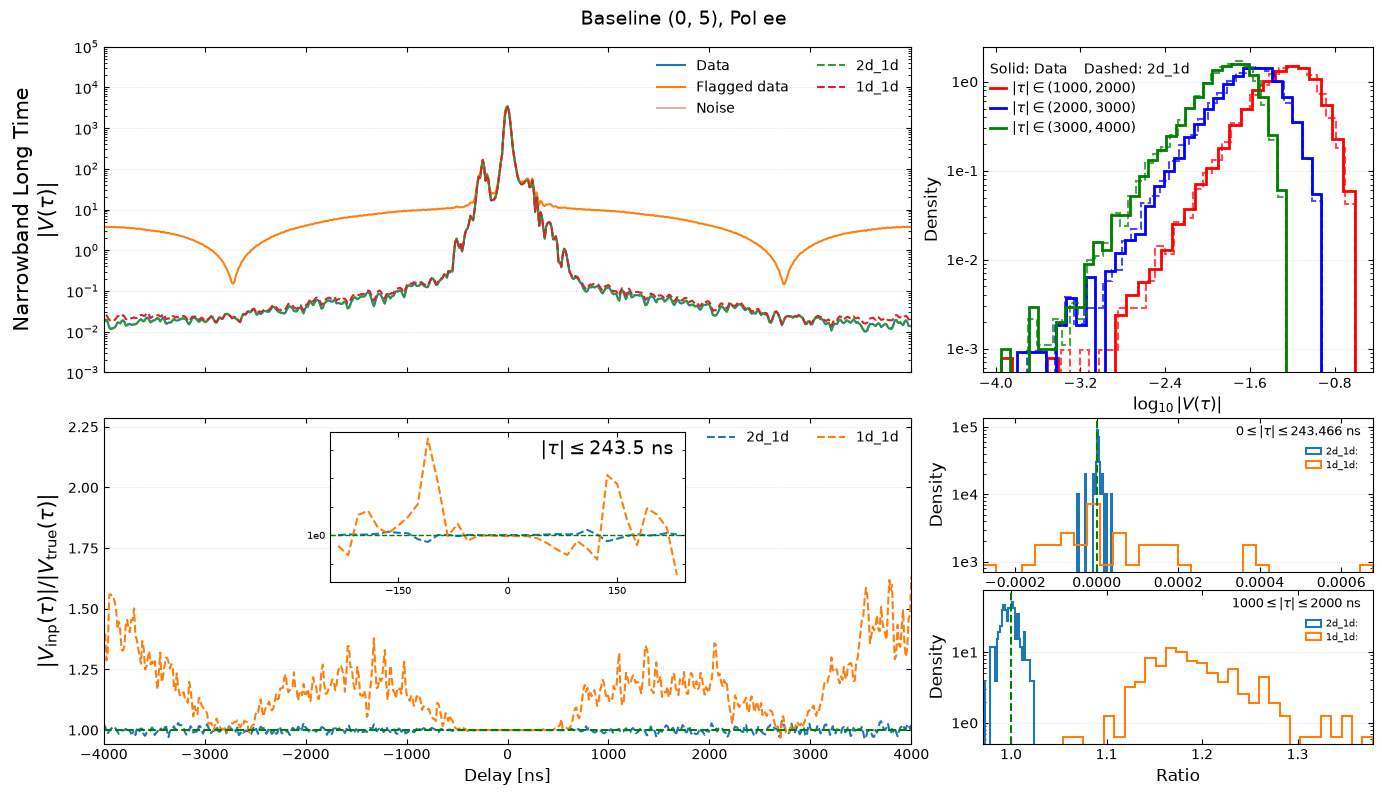

Plotting: Wideband Long Time


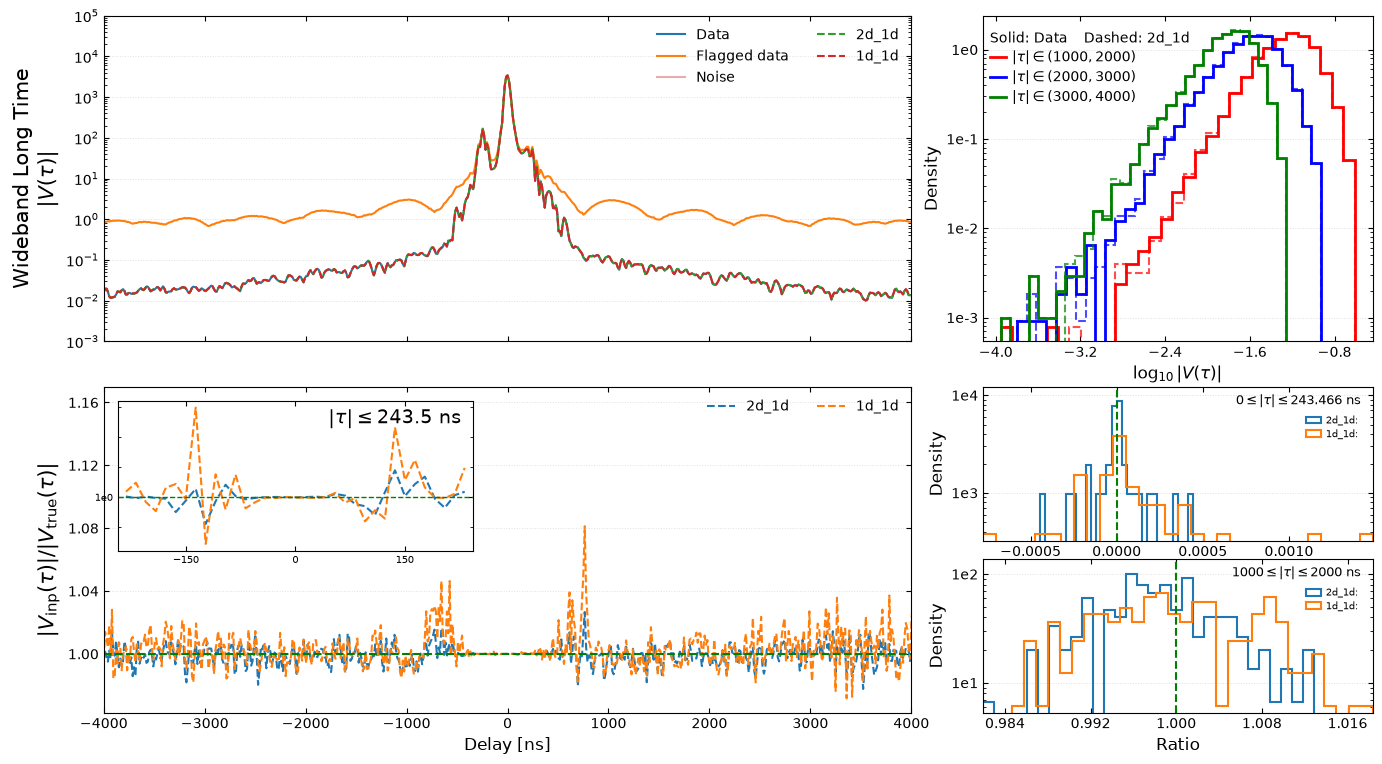

In [10]:
import gc
import glob
import importlib
import inspect
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import gpytorch

from pyuvdata import UVData
import bayeslim as ba
import gprlim
from gprlim import kernels
from bayeslim.fft import FFT


# ============================================================
# Local modules
# ============================================================

sys.path.append("./")
sys.path.append("../../")

import utils_load
from utils_load import save_vd_inp, load_vd_inp

import gp_utils
importlib.reload(gp_utils)

import utils_Vtau4
importlib.reload(utils_Vtau4)

from utils_Vtau4 import (
    coherent_reference_average,
    coherent_inpaint_average,
    create_delay_figure,
    get_delay_quantities,
    get_ratio_hist_values,
    get_horizon_delay_ns,
    plot_delay_histograms,
    plot_reference_delay_curves,
    plot_method_curves,
    plot_ratio_inset,
    plot_ratio_histogram,
    make_ratio_label,
    format_delay_axis,
    format_delay_hist_axis,
    format_ratio_axis,
    format_ratio_inset_axis,
    format_ratio_hist_axis,
    finalize_delay_figure,
)


print("gprlim path:")
print(gprlim.__file__)

print("\nutils_load module path:")
print(inspect.getmodule(save_vd_inp).__file__)

print("\ngp_utils path:")
print(gp_utils.__file__)

print("\nutils_Vtau4 path:")
print(utils_Vtau4.__file__)


gpytorch.settings.max_cholesky_size._set_value(1_000)
torch.set_default_dtype(torch.float64)

device = "cpu"


# ============================================================
# 1. Input data
# ============================================================

flag_file = (
    "/Users/alliswell48/radio_gpr_work/shao1/1.ideal_mock/"
    "gpr_data/version2/"
    "zen.h6c_idr3.2459951.flag_waterfall_round2.npz"
)

freq_chans = range(0, 600)
time_ints = range(80, 1680)

# Ideal simulation:
# dfile = "gpr_data/version2/zen.h6c_idr2_validation.sum.uvh5"

# Corrupted/coupled simulation:
dfile = sorted(
    glob.glob(
        "/Volumes/YUNYUNShao/gpr_data/corrupted data/"
        "zen.h6c_idr2_validation.24582*.sum.coupled.h5"
    )
)

if len(dfile) == 0:
    raise FileNotFoundError("No input visibility files matched dfile.")


# ============================================================
# 2. Optional data modifications
# ============================================================

inflate_data = False
add_gains = False
add_noise = False
add_reflection = False


# ============================================================
# 3. Inpainting methods
# ============================================================

inpaint_method_all = ["2d_1d", "1d_1d"]

# Other possible choices:
# inpaint_method_all = ["2d", "2d_1d", "1d_1d", "freq"]


# ============================================================
# 4. Time chunk size
# ============================================================

Ntime_chunks = 200


# ============================================================
# 5. Real flags
# ============================================================

add_real_flags = False


# ============================================================
# 6. Simulated flag patterns
# ============================================================

flag_types_all = [
    #"narrowband_full_time",
    #"wideband_full_time",
    #"ultraband_short_time",
    #"fullband_short_time",
    #"narrowband_short_time",
    "narrowband_long_time",
    "wideband_long_time",
    #"randn",
]


# ============================================================
# 7. Polarization and baselines
# ============================================================

polsi = "ee"
#blall = [(0, 1), (0, 5), (0, 10)]
blall = [ (0, 5)]


# ============================================================
# 8. Saved inpainting results
# ============================================================

inpaint_root_dir = (
    "/Volumes/YUNYUNShao/"
    "radio_gpr_work_great_lake/"
    "3.shao_instru/inpaint_results"
)


# ============================================================
# 9. Load autocorrelation and metadata
# ============================================================

vd_auto, meta_auto = gp_utils.load_uvdata(
    dfile,
    bls=[(0, 0)],
    pols=[polsi],
    time_ints=time_ints,
    freq_chans=freq_chans,
)

autocorr = vd_auto.data[0, 0]

freqs = meta_auto["freqs"] / 1e6
lsts = meta_auto["lsts"]
times = (meta_auto["times"] - meta_auto["times"][0]) * 24 * 3600

Ntimes = len(times)
Nfreqs = len(freqs)

reds = meta_auto["reds"]
antp = meta_auto["antp"]

ants = list(antp.keys())
antpos = torch.stack(list(antp.values()))

red_bls = meta_auto["bls"]
all_pols = meta_auto["pols"]

integration_time_s = np.diff(meta_auto["times"])[0] * 24 * 3600
channel_width_hz = np.diff(meta_auto["freqs"])[0]

noise_amp = autocorr.real / np.sqrt(
    integration_time_s * channel_width_hz
)

print("Ntimes:", Ntimes)
print("Nfreqs:", Nfreqs)
print("Polarization:", polsi)

# The autocorrelation object is no longer needed after noise_amp is computed.
del vd_auto
gc.collect()


# ============================================================
# 10. Loop over baselines
# ============================================================

for bl in blall:

    # --------------------------------------------------------
    # Identify redundant group and horizon delay
    # --------------------------------------------------------

    red_ind = np.where([bl in red for red in reds])[0][0]
    bls = reds[red_ind][:]

    representative_bl = bls[0]
    bl_vec = (
        antp[representative_bl[1]]
        - antp[representative_bl[0]]
    )
    bl_len = bl_vec.norm()

    tau_horizon = get_horizon_delay_ns(bl_len)

    print("\n" + "=" * 70)
    print(f"Baseline: {bl}")
    print(f"Baseline length: {float(bl_len):.3f} m")
    print(f"Horizon delay: {tau_horizon:.3f} ns")
    print("=" * 70)


    # --------------------------------------------------------
    # Load all baselines in this redundant group
    # --------------------------------------------------------

    vd, meta = gp_utils.load_uvdata(
        dfile,
        bls=bls,
        time_ints=time_ints,
        freq_chans=freq_chans,
        pols=[polsi],
        device=device,
    )


    # --------------------------------------------------------
    # Optional modifications
    # --------------------------------------------------------

    if inflate_data and vd.Nbls == 1:
        vd = vd.inflate_by_redundancy(
            bls=reds[red_ind]
        )

    if add_reflection:
        reflection = (
            torch.exp(
                2j * np.pi * 2000e-9 * freqs * 1e6
            )
            + torch.exp(
                -2j * np.pi * 2000e-9 * freqs * 1e6
            )
        )
        vd.data *= 1 + 1e-2 * reflection

    if add_gains:
        gains = (
            torch.randn(
                vd.Nbls,
                device=vd.data.device,
            )
            / 10
            + 1
        )
        vd.data *= gains[:, None, None]


    # --------------------------------------------------------
    # Noise-only reference
    # --------------------------------------------------------

    ns_draw = (
        torch.randn_like(vd.data)
        * noise_amp
        * 1e-10
    )

    if add_noise:
        ns_draw = (
            torch.randn_like(vd.data)
            * noise_amp
            * 1e-6
        )
        vd.data += ns_draw


    # --------------------------------------------------------
    # Frequency-to-delay Fourier transform
    # --------------------------------------------------------

    FT1 = FFT(
        dim=-1,
        N=vd.data.shape[-1],
        ndim=2,
        window="bh",
        dx=(freqs[1] - freqs[0]) / 1e3,
    )


    # ========================================================
    # Loop over flagging patterns
    # ========================================================

    for flag_idx, flag_typesi in enumerate(flag_types_all):

        flag_types = [flag_typesi]
        flag_N = [20]


        # ----------------------------------------------------
        # Figure title
        # ----------------------------------------------------

        if flag_typesi is None:
            flag_title = (
                "Real Flags"
                if add_real_flags
                else "No Flags"
            )
        elif add_real_flags:
            flag_title = (
                "Real Flags + "
                + flag_typesi.replace("_", " ").title()
            )
        else:
            flag_title = flag_typesi.replace("_", " ").title()

        print(f"Plotting: {flag_title}")


        # ----------------------------------------------------
        # Simulated flags
        # ----------------------------------------------------

        flags = gp_utils.simulate_flags(
            flag_types,
            flag_N,
            Ntimes,
            Nfreqs,
            seed=0,
        ).bool()

        if add_gains:
            flags = flags.expand(
                vd.data.shape[-3:]
            ).clone()

            for i in range(1, vd.Nbls):
                flags[i] = gp_utils.simulate_flags(
                    flag_types,
                    flag_N,
                    Ntimes,
                    Nfreqs,
                    seed=i,
                ).bool()


        # ----------------------------------------------------
        # Add real flags
        # ----------------------------------------------------

        if add_real_flags:
            real_flags = np.load(flag_file)["flags"][
                time_ints
            ][:, freq_chans, 0]

            real_flags = torch.as_tensor(
                real_flags,
                dtype=torch.bool,
                device=device,
            )

            flags = flags | real_flags


        # ----------------------------------------------------
        # Noise variance
        # ----------------------------------------------------

        noise_var = (
            noise_amp.pow(2)
            .expand(flags.shape)
            .clone()
            * 1e-5
        )

        noise_var[flags] = noise_var.mean() * 1e6


        # ====================================================
        # Figure layout
        # ====================================================

        inset_location = "upper center"

        if flag_typesi == "wideband_full_time" or flag_typesi == "wideband_long_time":
            inset_location = "upper left"

        (
            fig,
            ax_delay,
            ax_delay_hist,
            ax_ratio,
            ax_ratio_inset,
            # First stacked axis: upper histogram.
            ax_ratio_hist_horizon,
            # Second stacked axis: lower histogram.
            ax_ratio_hist_full,
        ) = create_delay_figure(
            loc0=inset_location
        )

        hist_colors = ["r", "b", "g"]
        tau_ranges = [1000, 2000, 3000]


        # ----------------------------------------------------
        # Ratio-histogram ranges
        # ----------------------------------------------------

        # Main science range.
        full_tmin = 1000.0
        full_tmax = 2000.0

        # Baseline-dependent horizon range.
        horizon_tmin = 0.0
        horizon_tmax = float(tau_horizon)


        # ====================================================
        # Compute method-independent averages only once
        # ====================================================

        (
            avg_times,
            time_wgts,
            vd_avg,
            vd_flg_avg,
            vd_ns_avg,
        ) = coherent_reference_average(
            vd=vd,
            flags=flags,
            ns_draw=ns_draw,
            Ntimes=Ntimes,
            Nelem=20,
        )

        ratio_hist_full_all = []
        ratio_hist_horizon_all = []
        delay_for_format = None


        # ====================================================
        # Loop over inpainting methods
        # ====================================================

        for inpaint_methodi in inpaint_method_all:

            # ------------------------------------------------
            # Load saved inpainted data
            # ------------------------------------------------

            vd_inp = load_vd_inp(
                root_dir=inpaint_root_dir,
                vd=vd,
                bl=bl,
                flag_typesi=flag_typesi,
                add_real_flags=add_real_flags,
                inpaint_method=inpaint_methodi,
                freq_chans=freq_chans,
                time_ints=time_ints,
                polsi=polsi,
                device=device,
                Ntime_chunks=Ntime_chunks,
            )


            # ------------------------------------------------
            # Average only the current inpainting result
            # ------------------------------------------------

            vd_inp_avg = coherent_inpaint_average(
                vd_inp=vd_inp,
                avg_times=avg_times,
                time_wgts=time_wgts,
            )


            # ------------------------------------------------
            # Delay-space quantities
            # ------------------------------------------------

            (
                p_d,
                p_i,
                data_delay,
                flg_delay,
                inp_delay,
                ns_delay,
                delay,
                ratio,
            ) = get_delay_quantities(
                vd_avg,
                vd_flg_avg,
                vd_inp_avg,
                vd_ns_avg,
                FT1,
            )

            delay_for_format = delay


            # ------------------------------------------------
            # Delay-amplitude histograms
            # ------------------------------------------------

            plot_delay_histograms(
                ax_delay_hist,
                p_d,
                p_i,
                delay,
                inpaint_methodi,
                inpaint_method_all[0],
                tau_ranges,
                hist_colors,
            )


            # ------------------------------------------------
            # Main ratio histogram: 1000–2000 ns
            # ------------------------------------------------

            ratio_hist_full = get_ratio_hist_values(
                ratio,
                delay,
                tau_min=full_tmin,
                tau_max=full_tmax,
            )

            if ratio_hist_full.size > 0:
                ratio_hist_full_all.append(
                    ratio_hist_full
                )

            full_method_label = make_ratio_label(
                inpaint_methodi,
                ratio_hist_full,
            )


            # ------------------------------------------------
            # Horizon ratio histogram
            # ------------------------------------------------

            ratio_hist_horizon = get_ratio_hist_values(
                ratio,
                delay,
                tau_min=horizon_tmin,
                tau_max=horizon_tmax,
            )

            if ratio_hist_horizon.size > 0:
                ratio_hist_horizon_all.append(
                    ratio_hist_horizon
                )

            horizon_method_label = make_ratio_label(
                inpaint_methodi,
                ratio_hist_horizon,
            )


            # ------------------------------------------------
            # Reference curves: plot once
            # ------------------------------------------------

            if inpaint_methodi == inpaint_method_all[0]:
                plot_reference_delay_curves(
                    ax_delay,
                    delay,
                    data_delay,
                    flg_delay,
                    ns_delay,
                )


            # ------------------------------------------------
            # Full delay and ratio curves
            # ------------------------------------------------

            plot_method_curves(
                ax_delay,
                ax_ratio,
                delay,
                inp_delay,
                ratio,
                inpaint_methodi,
            )


            # ------------------------------------------------
            # Ratio inset inside the horizon
            # ------------------------------------------------

            plot_ratio_inset(
                ax_ratio_inset,
                delay,
                ratio,
                inpaint_methodi,
                tau_horizon,
            )


            # ------------------------------------------------
            # Upper histogram: horizon range
            # ------------------------------------------------

            plot_ratio_histogram(
                ax_ratio_hist_horizon,
                ratio_hist_horizon,
                horizon_method_label,
            )


            # ------------------------------------------------
            # Lower histogram: 1000–2000 ns
            # ------------------------------------------------

            plot_ratio_histogram(
                ax_ratio_hist_full,
                ratio_hist_full,
                full_method_label,
            )


            # ------------------------------------------------
            # Delete method-dependent arrays
            # ------------------------------------------------

            del vd_inp
            del vd_inp_avg
            del p_i
            del inp_delay
            del ratio
            del ratio_hist_full
            del ratio_hist_horizon

            gc.collect()


        # ====================================================
        # Format all panels
        # ====================================================

        format_delay_axis(
            ax_delay,
            flag_title,
        )

        format_delay_hist_axis(
            ax_delay_hist,
        )


        # The full-range ratio panel may need more upper padding
        # for specific flagging patterns.
        upper_padding_percent = 120

        if flag_typesi == "ultraband_short_time":
            upper_padding_percent = 500
        elif flag_typesi == "narrowband_short_time":
            upper_padding_percent = 200
        elif flag_typesi == "wideband_full_time":
            upper_padding_percent = 200
        elif flag_typesi == "wideband_long_time":
            upper_padding_percent = 350


        format_ratio_axis(
            ax_ratio,
            delay=delay_for_format,
            tau_exclude=tau_horizon,
            lower_percentile=0.5,
            upper_percentile=99.5,
            lower_padding_percent=100,
            upper_padding_percent=upper_padding_percent,
        )

        format_ratio_inset_axis(
            ax_ratio_inset,
            tau_horizon,
        )


        # ----------------------------------------------------
        # Upper histogram: horizon range
        # ----------------------------------------------------

        format_ratio_hist_axis(
            ax_ratio_hist_horizon,
            ratio_hist_all=ratio_hist_horizon_all,
            x_min_fraction=1.0,
            x_max_fraction=1.0,
            tau_min=horizon_tmin,
            tau_max=horizon_tmax,
            fontsize=7,
            show_xlabel=True,
        )


        # ----------------------------------------------------
        # Lower histogram: 1000–2000 ns
        # ----------------------------------------------------

        format_ratio_hist_axis(
            ax_ratio_hist_full,
            ratio_hist_all=ratio_hist_full_all,
            x_min_fraction=1.0,
            x_max_fraction=1.0,
            tau_min=full_tmin,
            tau_max=full_tmax,
            fontsize=7,
            show_xlabel=True,
        )


        # ====================================================
        # Final layout and display
        # ====================================================

        finalize_delay_figure(
            fig,
            ax_delay,
            ax_ratio,
            flag_idx,
            bl,
            polsi,
        )

        plt.close(fig)


        # ====================================================
        # Cleanup after this flagging pattern
        # ====================================================

        del avg_times
        del time_wgts
        del vd_avg
        del vd_flg_avg
        del vd_ns_avg

        del ratio_hist_full_all
        del ratio_hist_horizon_all
        del delay_for_format
        del flags
        del noise_var

        gc.collect()


    # ========================================================
    # Cleanup after this baseline
    # ========================================================

    del vd
    del meta
    del ns_draw
    del FT1

    gc.collect()


In [3]:
1

1